### aim: 

### date: 

In [3]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [4]:
# ================================
# IMPORTS
# ================================
import os
import glob
import pickle
import time
import warnings
from datetime import datetime
from importlib import reload

import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc
import seawater

import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
import matplotlib.path as mpath

import cartopy as cp
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from cmocean import cm

# Jupyter magic
%matplotlib inline

# Suppress warnings
warnings.filterwarnings('ignore')

# ================================
# FONT CONFIGURATION
# ================================
# Disable LaTeX (use mathtext with chosen font)
plt.rcParams['text.usetex'] = False

# Base font size
fs = 11

# Path to Gill Sans
gill_sans_path = "/gpfs/home/mep22dku/scratch/FONTS/gill-sans/GillSansMedium.otf"

# Try to load custom font
if os.path.exists(gill_sans_path):
    font_manager.fontManager.addfont(gill_sans_path)
    gill_font_name = font_manager.FontProperties(fname=gill_sans_path).get_name()
    chosen_font = gill_font_name
    print(f"✓ Using custom font: {gill_font_name}")
else:
    chosen_font = "DejaVu Sans"
    print("⚠️ Gill Sans not found, using fallback: DejaVu Sans")

# Apply font settings
rcParams.update({
    'font.size': fs,
    'font.family': chosen_font,
    'axes.titlesize': fs,
    'axes.labelsize': fs,
    'xtick.labelsize': fs,
    'ytick.labelsize': fs,
    'legend.fontsize': fs,
    'mathtext.fontset': 'custom',
    'mathtext.rm': chosen_font,
    'mathtext.it': chosen_font,
    'mathtext.bf': chosen_font,
})

✓ Using custom font: Gill Sans


In [5]:
mask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_nicedims.nc')


## assorted snippets

#### AMOC timeseries

Saved to ./plts/AMOC_26N_timeseries_6runs.png


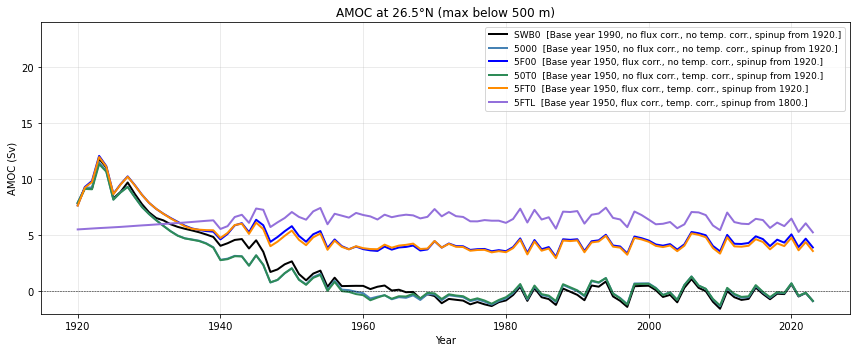

In [3]:
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

# ===== INPUTS =====
clims_dir = '/gpfs/data/greenocean/users/mep22dku/clims/'
yrst      = 1920
yrend     = 2024

run_descriptions = {
    "SWB0": "Base year 1990, no flux corr., no temp. corr., spinup from 1920.",
    "5000": "Base year 1950, no flux corr., no temp. corr., spinup from 1920.",
    "5F00": "Base year 1950, flux corr., no temp. corr., spinup from 1920.",
    "50T0": "Base year 1950, no flux corr., temp. corr., spinup from 1920.",
    "5FT0": "Base year 1950, flux corr., temp. corr., spinup from 1920.",
    "5FTL": "Base year 1950, flux corr., temp. corr., spinup from 1800.",
}

colors = ['black', 'steelblue', 'b', 'seagreen', 'darkorange', 'mediumpurple']

# ===== PLOT =====
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title('AMOC at 26.5°N (max below 500 m)')

for (run, desc), color in zip(run_descriptions.items(), colors):
    model = f'TOM12_TJ_{run}'
    fpath = Path(clims_dir) / model / f'{model}_AMOC_26N_{yrst}_{yrend}.nc'
    if fpath.exists():
        ds = xr.open_dataset(fpath, engine='netcdf4')
        da = ds['AMOC_26N'].groupby('time_counter.year').mean()
        ax.plot(da.year, da.values, color=color, linewidth=2, label=f'{run}  [{desc}]')
    else:
        print(f"Missing: {fpath}")

ax.set_ylabel('AMOC (Sv)')
ax.set_xlabel('Year')
ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim([-2, 24])

fig.tight_layout()
outfile = './plts/AMOC_26N_timeseries_6runs.png'
fig.savefig(outfile, dpi=150, bbox_inches='tight')
print(f"Saved to {outfile}")
plt.show()

## streamfunctions

✓ Using custom font: Gill Sans


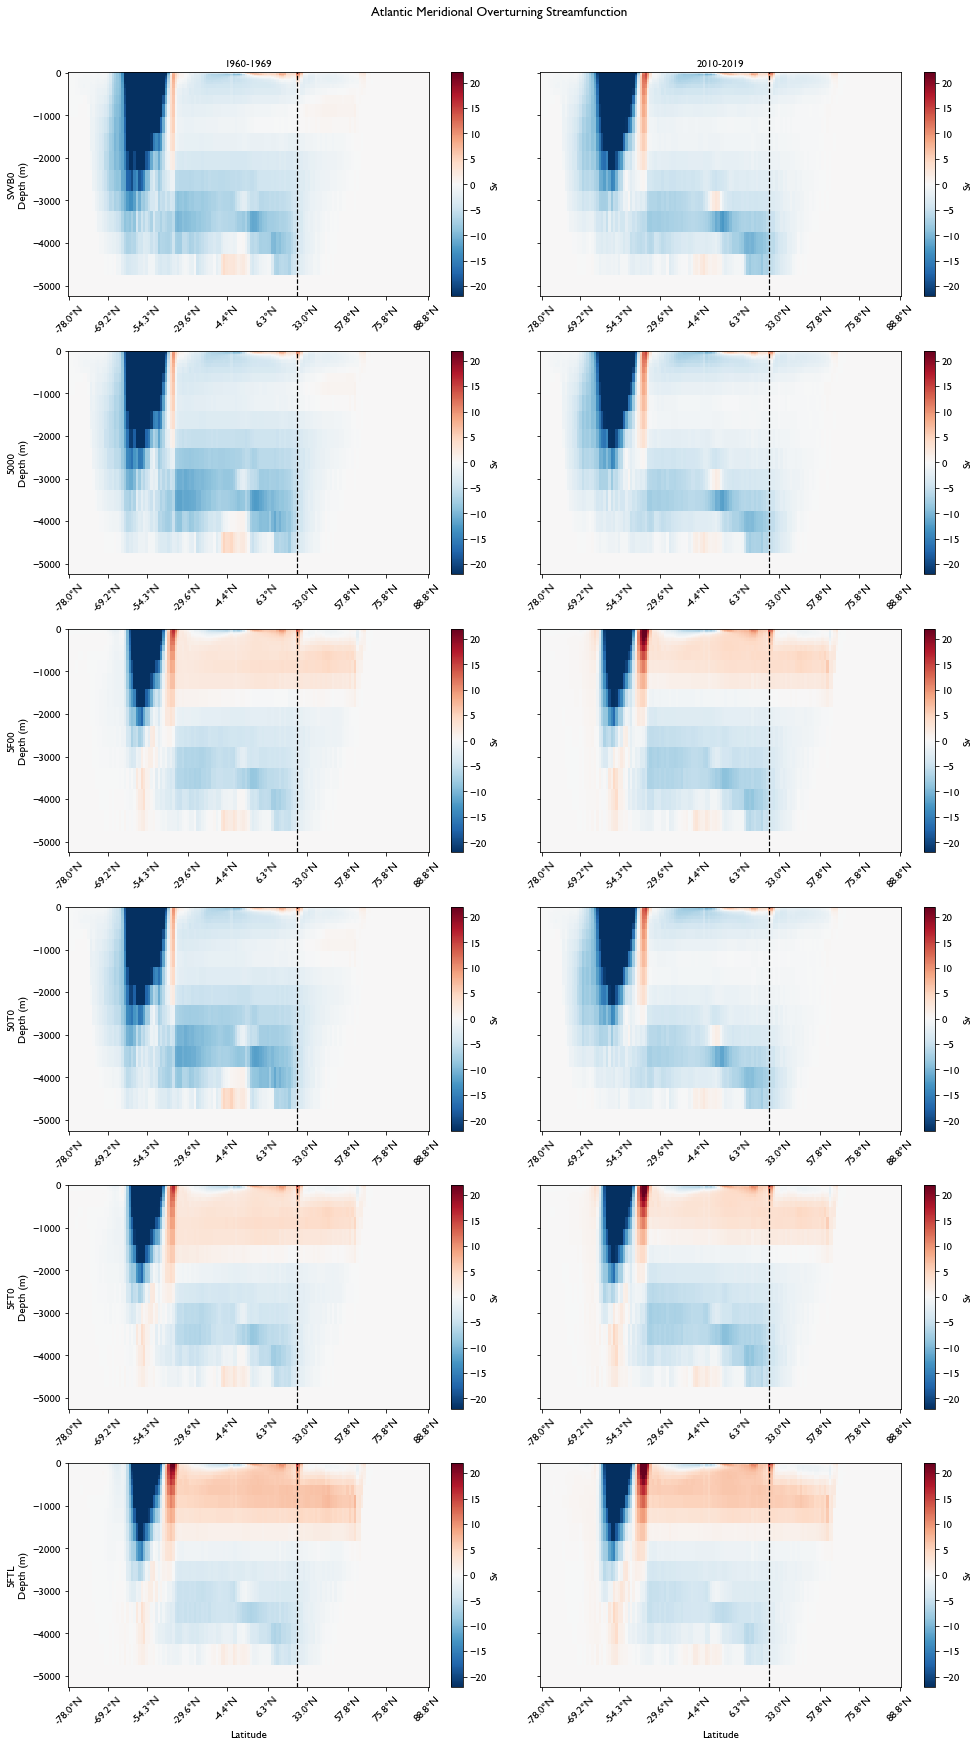

In [4]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
import numpy as np
import os

# ================================
# FONT CONFIGURATION
# ================================
plt.rcParams['text.usetex'] = False
fs = 11
gill_sans_path = "/gpfs/home/mep22dku/scratch/FONTS/gill-sans/GillSansMedium.otf"
if os.path.exists(gill_sans_path):
    font_manager.fontManager.addfont(gill_sans_path)
    gill_font_name = font_manager.FontProperties(fname=gill_sans_path).get_name()
    chosen_font = gill_font_name
    print(f"✓ Using custom font: {gill_font_name}")
else:
    chosen_font = "DejaVu Sans"
    print("⚠️ Gill Sans not found, using fallback: DejaVu Sans")
rcParams.update({
    'font.size': fs,
    'font.family': chosen_font,
    'axes.titlesize': fs,
    'axes.labelsize': fs,
    'xtick.labelsize': fs,
    'ytick.labelsize': fs,
    'legend.fontsize': fs,
    'mathtext.fontset': 'custom',
    'mathtext.rm': chosen_font,
    'mathtext.it': chosen_font,
    'mathtext.bf': chosen_font,
})

# ================================
# DATA
# ================================
DATA_DIR = '/gpfs/data/greenocean/users/mep22dku/clims'

run_descriptions = {
    "SWB0": "Base year 1990, no flux corr., no temp. corr., spinup from 1920.",
    "5000": "Base year 1950, no flux corr., no temp. corr., spinup from 1920.",
    "5F00": "Base year 1950, flux corr., no temp. corr., spinup from 1920.",
    "50T0": "Base year 1950, no flux corr., temp. corr., spinup from 1920.",
    "5FT0": "Base year 1950, flux corr., temp. corr., spinup from 1920.",
    "5FTL": "Base year 1950, flux corr., temp. corr., spinup from 1800.",
}

periods = {
    '1960-1969': (1960, 1969),
    '2010-2019': (2010, 2019),
}

# Load datasets: datasets[run][period_label] = ds
datasets = {}
for run, desc in run_descriptions.items():
    model = f'TOM12_TJ_{run}'
    datasets[run] = {}
    for label, (yrst, yrend) in periods.items():
        fpath = os.path.join(DATA_DIR, model, f'{model}_SF_{yrst}_{yrend}.nc')
        if os.path.exists(fpath):
            datasets[run][label] = xr.open_dataset(fpath)
        else:
            print(f"Missing: {fpath}")
            datasets[run][label] = None

# ================================
# PLOT  (6 rows x 2 cols)
# ================================
nrows = len(run_descriptions)
ncols = len(periods)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows),
                         sharex=False, sharey=True)

period_labels = list(periods.keys())

for row, (run, desc) in enumerate(run_descriptions.items()):
    for col, period_label in enumerate(period_labels):
        ax  = axes[row, col]
        ds  = datasets[run][period_label]

        if ds is None:
            ax.set_visible(False)
            continue

        y_    = ds['y'].values
        dep_  = ds['depthw'].values
        lats_ = ds['nav_lat'][0, :, 0].values

        idx_26_       = int(np.argmin(np.abs(lats_ - 26.5)))
        tick_indices_ = np.linspace(0, len(y_) - 1, 10, dtype=int)
        ticklabels_   = [f'{lats_[i]:.1f}°N' for i in tick_indices_]

        data = ds['zomsfatl'].values
        pc   = ax.pcolormesh(y_, dep_, data, cmap='RdBu_r', vmin=-22, vmax=22, shading='auto')
        plt.colorbar(pc, ax=ax, label='Sv')

        ax.axvline(x=y_[idx_26_], color='black', linewidth=1.2, linestyle='--', label='26.5°N')
        ax.set_xticks(y_[tick_indices_])
        ax.set_xticklabels(ticklabels_, rotation=45)

        # Left column: y-label with run name; right column: nothing
        if col == 0:
            ax.set_ylabel(f'{run}\nDepth (m)')
        # Top row: period title
        if row == 0:
            ax.set_title(period_label, fontweight='bold')
        # Bottom row: x-label
        if row == nrows - 1:
            ax.set_xlabel('Latitude')

axes[-1, -1].set_xlabel('Latitude')

fig.suptitle('Atlantic Meridional Overturning Streamfunction', fontweight='bold', y=1.01)
plt.tight_layout()
os.makedirs('./plts', exist_ok=True)
plt.savefig('./plts/SF_6runs_2periods.png', dpi=150, bbox_inches='tight')
plt.show()

## the temperature correction appears not to have made much of a difference, checking that SST looks different in the runs

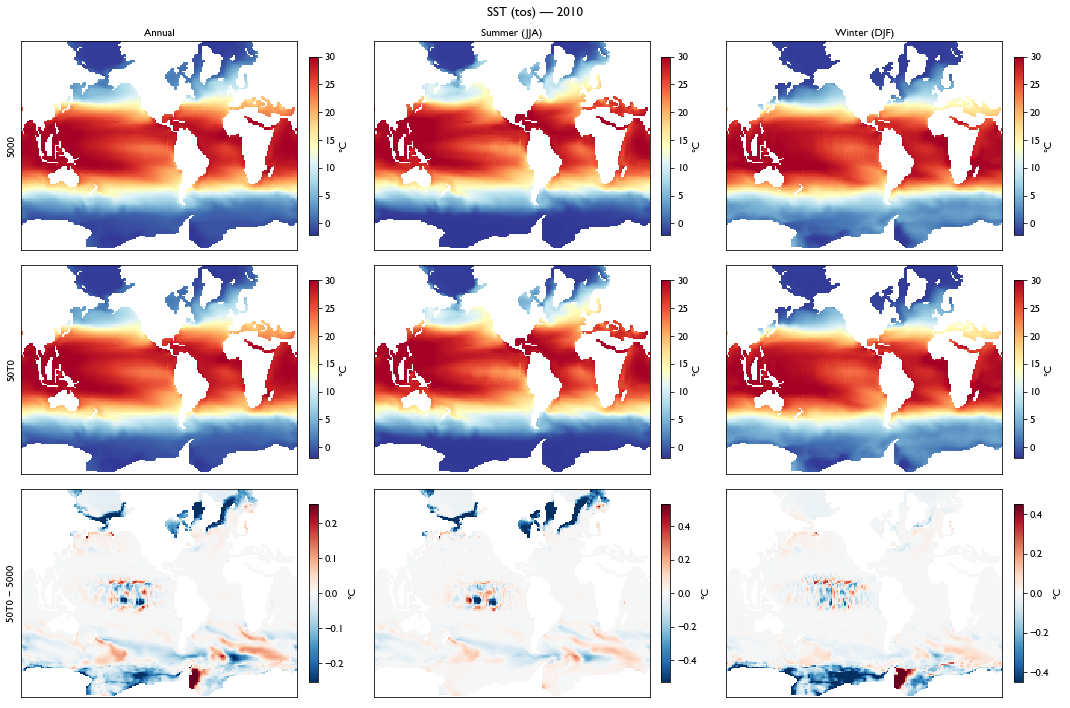

In [6]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# ================================
# CONFIG
# ================================
DATA_DIR = '/gpfs/afm/greenocean/software/runs'
year     = 2010
fname    = f'ORCA2_1m_{year}0101_{year}1231_grid_T.nc'

models = ['TOM12_TJ_5000', 'TOM12_TJ_50T0']

season_months = {
    'Annual':       None,
    'Summer (JJA)': [6, 7, 8],
    'Winter (DJF)': [12, 1, 2],
}

# ================================
# LOAD & COMPUTE SEASONAL MEANS
# ================================
data = {}  # data[model][season] = 2D array
for model in models:
    fpath = f'{DATA_DIR}/{model}/{fname}'
    ds    = xr.open_dataset(fpath)
    tos   = ds['tos']
    data[model] = {}
    for season, months in season_months.items():
        if months is None:
            mean = tos.mean(dim='time_counter')
        else:
            mean = tos.sel(time_counter=tos.time_counter.dt.month.isin(months)).mean(dim='time_counter')
        data[model][season] = mean.where(mean != 0)

# ================================
# PLOT  (3 rows x 3 cols)
# ================================
fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True, sharey=True)

row_labels = [m.replace('TOM12_TJ_', '') for m in models] + ['50T0 − 5000']

for col, season in enumerate(season_months):
    # --- rows 0 & 1: individual models ---
    for row, model in enumerate(models):
        ax = axes[row, col]
        pc = ax.pcolormesh(data[model][season].values, cmap='RdYlBu_r',
                           vmin=-2, vmax=30, shading='auto')
        plt.colorbar(pc, ax=ax, label='°C', fraction=0.03, pad=0.04)
        if row == 0:
            ax.set_title(season, fontweight='bold')
        if col == 0:
            ax.set_ylabel(row_labels[row], fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])

    # --- row 2: difference ---
    ax   = axes[2, col]
    diff = data['TOM12_TJ_50T0'][season] - data['TOM12_TJ_5000'][season]
    vlim = np.nanpercentile(np.abs(diff.values), 98)  # symmetric, robust limits
    pc   = ax.pcolormesh(diff.values, cmap='RdBu_r', vmin=-vlim, vmax=vlim, shading='auto')
    plt.colorbar(pc, ax=ax, label='°C', fraction=0.03, pad=0.04)
    if col == 0:
        ax.set_ylabel(row_labels[2], fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f'SST (tos) — {year}', fontweight='bold')
plt.tight_layout()
plt.savefig('./plts/SST_5000_50T0_2010.png', dpi=150, bbox_inches='tight')
plt.show()